# Student Performance ML Workflow

This notebook turns the dataset exploration into a full machine learning workflow for predicting the final grade `G3`.


## 1. Problem framing

We want to predict a student's final grade using the other columns in the dataset. This is a regression problem because `G3` is a numeric value.


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


In [20]:
df = pd.read_csv("../data/student_data.csv")
print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [21]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [22]:
df["G3"].describe()


count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64

## 2. Feature and target setup

We separate the input features (`X`) from the value we want to predict (`y`).


In [23]:
X = df.drop(columns=["G3"])
y = df["G3"]

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")


Feature matrix shape: (395, 32)
Target shape: (395,)


In [24]:
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']
Categorical features: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


## 3. Quick analysis

Before training, it helps to inspect a few relationships that might matter for the final grade.


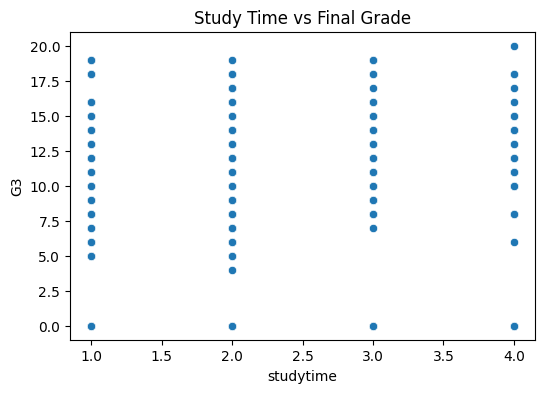

In [25]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x="studytime", y="G3")
plt.title("Study Time vs Final Grade")
plt.show()


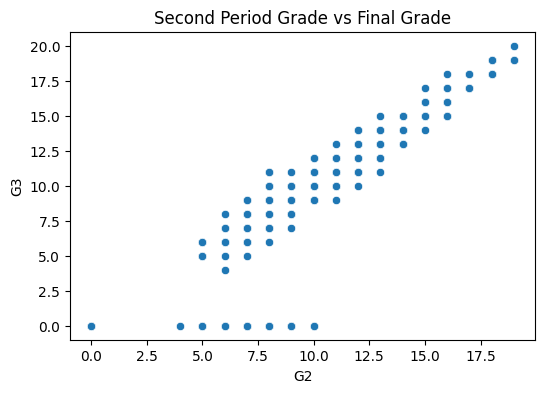

In [26]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x="G2", y="G3")
plt.title("Second Period Grade vs Final Grade")
plt.show()


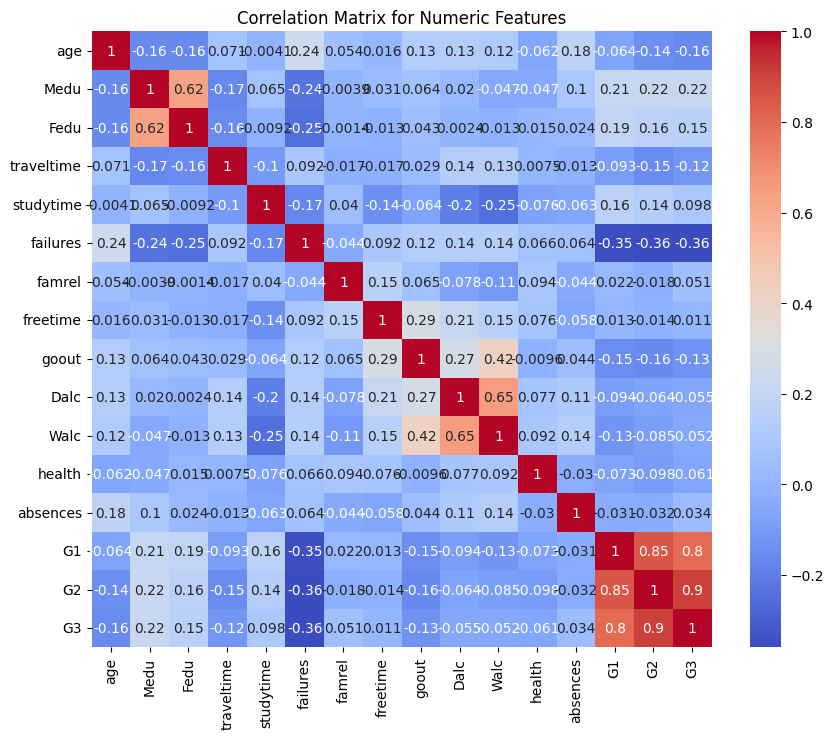

In [27]:
numeric_df = df.select_dtypes(include=["number"])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix for Numeric Features")
plt.show()


## 4. Train/test split and preprocessing

We keep part of the data aside for testing, and we preprocess numeric and categorical columns differently.


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training rows: {X_train.shape[0]}")
print(f"Testing rows: {X_test.shape[0]}")


Training rows: 316
Testing rows: 79


In [29]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
])


## 5. Baseline model: Linear Regression

Linear regression gives us a simple baseline that is easy to interpret.


In [30]:
def evaluate_model(name, pipeline, X_train, X_test, y_train, y_test):
    pipeline.fit(X_train, y_train)
    train_predictions = pipeline.predict(X_train)
    test_predictions = pipeline.predict(X_test)

    results = {
        "name": name,
        "pipeline": pipeline,
        "train_r2": r2_score(y_train, train_predictions),
        "test_r2": r2_score(y_test, test_predictions),
        "test_mae": mean_absolute_error(y_test, test_predictions),
        "test_rmse": mean_squared_error(y_test, test_predictions) ** 0.5,
        "predictions": test_predictions,
    }
    return results


In [31]:
linear_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression()),
])

linear_results = evaluate_model(
    "Linear Regression", linear_pipeline, X_train, X_test, y_train, y_test
)
pd.DataFrame([linear_results])[ ["name", "train_r2", "test_r2", "test_mae", "test_rmse"] ]


,name,train_r2,test_r2,test_mae,test_rmse
0,Linear Regression,0.865598,0.724134,1.646666,2.37837


In [32]:
linear_feature_names = linear_results["pipeline"].named_steps["preprocessor"].get_feature_names_out()
linear_coefficients = pd.DataFrame({
    "feature": linear_feature_names,
    "coefficient": linear_results["pipeline"].named_steps["model"].coef_,
})
linear_coefficients["abs_coefficient"] = linear_coefficients["coefficient"].abs()
linear_coefficients.sort_values("abs_coefficient", ascending=False).head(10)


,feature,coefficient,abs_coefficient
14,num__G2,0.957772,0.957772
36,cat__reason_home,-0.479745,0.479745
37,cat__reason_other,0.437128,0.437128
31,cat__Fjob_health,0.416316,0.416316
43,cat__schoolsup_yes,0.392826,0.392826
42,cat__schoolsup_no,-0.392826,0.392826
33,cat__Fjob_services,-0.359688,0.359688
26,cat__Mjob_health,-0.332658,0.332658
6,num__famrel,0.314962,0.314962
5,num__failures,-0.285781,0.285781


## 6. Comparison model: Random Forest

Random forests can model non-linear relationships and often perform better on mixed tabular data.


In [33]:
forest_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=200, random_state=42)),
])

forest_results = evaluate_model(
    "Random Forest", forest_pipeline, X_train, X_test, y_train, y_test
)
pd.DataFrame([forest_results])[ ["name", "train_r2", "test_r2", "test_mae", "test_rmse"] ]


,name,train_r2,test_r2,test_mae,test_rmse
0,Random Forest,0.984636,0.803584,1.187658,2.00687


In [34]:
forest_feature_names = forest_results["pipeline"].named_steps["preprocessor"].get_feature_names_out()
forest_importance = pd.DataFrame({
    "feature": forest_feature_names,
    "importance": forest_results["pipeline"].named_steps["model"].feature_importances_,
})
forest_importance.sort_values("importance", ascending=False).head(10)


,feature,importance
14,num__G2,0.787204
12,num__absences,0.114331
36,cat__reason_home,0.018982
0,num__age,0.009070
13,num__G1,0.005542
6,num__famrel,0.004970
11,num__health,0.004063
40,cat__guardian_mother,0.003701
8,num__goout,0.003611
4,num__studytime,0.003205


## 7. Tune the random forest

Now that we have a strong comparison model, we can try a small grid search to see whether a few parameter changes improve the score.


In [35]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
}

tuning_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42)),
])

grid_search = GridSearchCV(
    estimator=tuning_pipeline,
    param_grid=param_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1,
)

grid_search.fit(X_train, y_train)
print("Best cross-validation score:", round(grid_search.best_score_, 3))
print("Best parameters:", grid_search.best_params_)


Best cross-validation score: 0.906
Best parameters: {'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 100}


In [36]:
tuned_forest_results = evaluate_model(
    "Tuned Random Forest", grid_search.best_estimator_, X_train, X_test, y_train, y_test
)
pd.DataFrame([tuned_forest_results])[ ["name", "train_r2", "test_r2", "test_mae", "test_rmse"] ]


,name,train_r2,test_r2,test_mae,test_rmse
0,Tuned Random Forest,0.983744,0.801214,1.195197,2.018938


## 8. Compare results and inspect predictions

This is where we check which model performs better and whether the train/test scores suggest overfitting.


In [37]:
comparison_df = pd.DataFrame([
    {
        "model": linear_results["name"],
        "train_r2": linear_results["train_r2"],
        "test_r2": linear_results["test_r2"],
        "test_mae": linear_results["test_mae"],
        "test_rmse": linear_results["test_rmse"],
    },
    {
        "model": forest_results["name"],
        "train_r2": forest_results["train_r2"],
        "test_r2": forest_results["test_r2"],
        "test_mae": forest_results["test_mae"],
        "test_rmse": forest_results["test_rmse"],
    },
    {
        "model": tuned_forest_results["name"],
        "train_r2": tuned_forest_results["train_r2"],
        "test_r2": tuned_forest_results["test_r2"],
        "test_mae": tuned_forest_results["test_mae"],
        "test_rmse": tuned_forest_results["test_rmse"],
    },
])

comparison_df.sort_values("test_r2", ascending=False)


,model,train_r2,test_r2,test_mae,test_rmse
1,Random Forest,0.984636,0.803584,1.187658,2.006870
2,Tuned Random Forest,0.983744,0.801214,1.195197,2.018938
0,Linear Regression,0.865598,0.724134,1.646666,2.378370


In [38]:
predictions_df = pd.DataFrame({
    "actual": y_test.reset_index(drop=True),
    "linear_prediction": pd.Series(linear_results["predictions"]).round(2),
    "forest_prediction": pd.Series(forest_results["predictions"]).round(2),
    "tuned_forest_prediction": pd.Series(tuned_forest_results["predictions"]).round(2),
})
predictions_df.head(10)


,actual,linear_prediction,forest_prediction,tuned_forest_prediction
0,10,6.00,8.21,8.21
1,12,11.53,11.74,11.69
2,5,2.87,6.66,6.49
3,10,8.80,9.70,9.80
4,9,8.55,8.82,8.60
5,13,11.89,12.80,12.81
6,18,19.10,18.71,18.78
7,6,7.17,6.90,6.79
8,0,7.41,7.41,7.05
9,14,12.31,13.34,13.26


## 9. Takeaways

- We built a full ML workflow instead of stopping at exploration.
- We used a preprocessing pipeline so numeric and categorical columns are handled correctly.
- We compared a simple baseline to a stronger tree-based model.
- We tuned the random forest with a small grid search to learn how model parameters affect performance.
- We checked train and test scores to start building intuition about overfitting.

A strong next step after this notebook is to load the saved model, try feature selection, or build a tiny prediction app.
